# RL Gaming

---

## Setup

In [ ]:
from pathlib import Path

# from stable_baselines3 import PPO
from custom_callback import CustomCallback
from env_optimiser import EnvOptimiser
from feature_extractor import MinigridFeaturesExtractor
from levels_utils import (
    display_all_levels,
    # test_ppo_model_on_level,
)
from minigrid.wrappers import ImgObsWrapper, OneHotPartialObsWrapper
from minigrid_levels_env import MinigridLevelsEnv
from procedural_level import ProceduralLevel
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO

---

## Environment

### Random training levels

### Custom testing levels

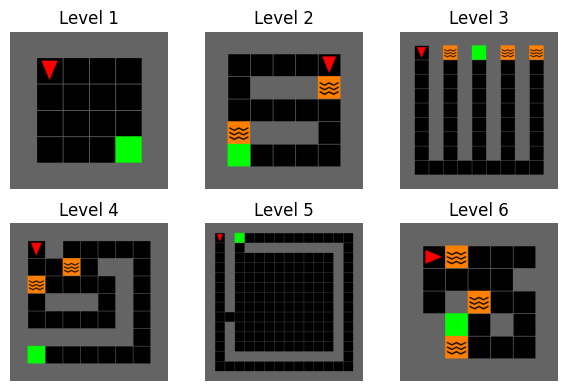

In [4]:
display_all_levels(max_cols=3)

---

## PPO

### Training

In [ ]:
n_envs = 8
n_timesteps = 5_000
freq = 100
eval_freq = max(freq // n_envs, 1)  # accounting for multiple environments

save_dir = Path("models/")
save_dir.mkdir(parents=True, exist_ok=True)

env = MinigridLevelsEnv(level_id=1)
optimiser = EnvOptimiser(env=env, n_envs=n_envs, wrapper_cls=[ImgObsWrapper], save_dir=save_dir)
vec_env_train = optimiser.build_vec_env()
policy_kwargs = {
    "features_extractor_class": MinigridFeaturesExtractor,
    "features_extractor_kwargs": {"features_dim": 128},
}
model_dir = optimiser.file_path.parent  # makes use of the same folder
callback = CustomCallback(check_freq=eval_freq, save_dir=model_dir, verbose=1)
model = PPO(policy="CnnPolicy", env=vec_env_train, policy_kwargs=policy_kwargs)
model.learn(total_timesteps=n_timesteps, callback=callback, progress_bar=True)

### Plots

## RecurrentPPO

### Training

In [ ]:
n_envs = 8
n_timesteps = 5_000
freq = 100
eval_freq = max(freq // n_envs, 1)

save_dir = Path("models/")
save_dir.mkdir(parents=True, exist_ok=True)

env = ProceduralLevel(difficulty=1000, max_steps=200)
optimiser = EnvOptimiser(
    env=env, n_envs=n_envs, wrapper_cls=[OneHotPartialObsWrapper, ImgObsWrapper], save_dir=save_dir
)
vec_env_train = optimiser.build_vec_env()
policy_kwargs = {
    "features_extractor_class": MinigridFeaturesExtractor,
    "features_extractor_kwargs": {"features_dim": 128},
}
model_dir = optimiser.file_path.parent
callback = CustomCallback(check_freq=eval_freq, save_dir=model_dir, verbose=1)
model = RecurrentPPO(policy="CnnLstmPolicy", env=vec_env_train, policy_kwargs=policy_kwargs)
model.learn(total_timesteps=n_timesteps, callback=callback, progress_bar=True)

### Plots

---